In [1]:
# Imports

import torch
from torch import randperm
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split, Subset, Dataset
import itertools
import numpy as np
from PIL import Image

from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights

In [2]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

transform = transforms.transforms.Compose([
    transforms.Resize((300,300)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    
])

dataset = datasets.ImageFolder(root = "../data/brain_tumor_dataset", transform=transform)

loader = DataLoader(dataset,
                    batch_size=32,
                    shuffle=True)

train_size = int(0.8*len(dataset))
val_size = int(0.1*len(dataset))
test_size = len(dataset) - val_size - train_size

train_set, val_set, test_set = random_split(dataset, [train_size, val_size, test_size], 
                                            generator=torch.Generator().manual_seed(8))

train_loader = DataLoader(train_set, batch_size=32, shuffle=True,
                          num_workers=4, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_set,   batch_size=32, shuffle=False,
                          num_workers=4, pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(test_set,  batch_size=32, shuffle=False,
                          num_workers=4, pin_memory=True, persistent_workers=True)

In [3]:
# TODO : Use gradual unfreezing approach on 3-4 models. Should be pretty straightforward to do this

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def _freeze_all(model: nn.Module):
    """Freeze every parameter in the model."""
    for param in model.parameters():
        param.requires_grad = False


def unfreeze_all(model: nn.Module, optimizer, new_lr: float):
    """
    Unfreeze every parameter and update the optimizer.
    Instead of adding a new group (which causes duplicates),
    we collect only the params NOT already in the optimizer.
    """
    # Collect params already registered in the optimizer
    already_in_optimizer = set()
    for group in optimizer.param_groups:
        for p in group["params"]:
            already_in_optimizer.add(id(p))

    # Unfreeze everything and collect the new params
    new_params = []
    for param in model.parameters():
        param.requires_grad = True
        if id(param) not in already_in_optimizer:
            new_params.append(param)

    model = model.to(DEVICE)

    # Only add params that aren't already tracked
    if new_params:
        optimizer.add_param_group({"params": new_params, "lr": new_lr})
        print(f"[Unfreeze] {len(new_params)} parameter groups unfrozen — new LR: {new_lr}")
    else:
        print("[Unfreeze] No new params to add — already fully unfrozen")

In [4]:
NUM_CLASSES = 4          # adjust to match your dataset
NUM_EPOCHS  = 10
LR_HEAD     = 1e-3       # learning rate when only the head is unfrozen
LR_FULL     = 1e-4       # learning rate after full unfreezing (lower to protect pretrained weights)
UNFREEZE_EPOCH = 5       # epoch at which all layers are unfrozen


def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for img, lbl in loader:
        img, lbl = img.to(DEVICE, non_blocking=True), lbl.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            outputs = model(img)
            loss = criterion(outputs, lbl)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * img.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(lbl).sum().item()
        total += lbl.size(0)

    return running_loss / total, correct / total
        


In [5]:
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix
import torch.nn.functional as F

def evaluate(model, loader, criterion, num_classes, k=2):

    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    top_k_correct = 0

    all_probs   = []   # softmax probabilities  (for AUC)
    all_preds   = []   # argmax predictions      (for F1, confusion matrix)
    all_labels  = []   # ground truth            (for everything)

    with torch.no_grad():
        for img, lbl in loader:
            img, lbl = img.to(DEVICE), lbl.to(DEVICE)
            outputs = model(img)
            loss = criterion(outputs, lbl)

            running_loss += loss.item() * img.size(0)   # ← bug fix: loss.item() not loss.item

            probs = F.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)

            # Top-1 accuracy
            correct += predicted.eq(lbl).sum().item()
            total   += lbl.size(0)                      # ← bug fix: lbl.size(0) not lbl.size()

            # Top-K accuracy
            top_k_correct += (outputs.topk(k, dim=1).indices == lbl.unsqueeze(1)).any(dim=1).sum().item()

            all_probs.append(probs.cpu())
            all_preds.append(predicted.cpu())
            all_labels.append(lbl.cpu())

    all_probs  = torch.cat(all_probs).numpy()
    all_preds  = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    avg_loss = running_loss / total
    acc      = correct / total
    top_k    = top_k_correct / total
    auc      = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    f1       = f1_score(all_labels, all_preds, average='weighted')
    cm       = confusion_matrix(all_labels, all_preds)

    return avg_loss, acc, top_k, auc, f1, cm, all_probs, all_labels

In [8]:
from torchvision.models import densenet121, DenseNet121_Weights

NUM_EPOCHS     = 5
UNFREEZE_EPOCH = 1   # unfreeze halfway through the 3 epochs

model = densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)

_freeze_all(model)

# Replace classifier (last layer)
in_features = model.classifier.in_features
model.classifier = nn.Linear(in_features, NUM_CLASSES)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()

scaler = torch.amp.GradScaler('cuda')


optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_HEAD, weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

best_val_acc = 0.0
unfrozen = False

train_losses    = []
dns_val_losses  = []
dns_val_accs    = []
dns_val_aucs    = []

for epoch in range(NUM_EPOCHS):

    if epoch == UNFREEZE_EPOCH and not unfrozen:
        unfreeze_all(model, optimizer, LR_FULL)
        unfrozen = True
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

    print(f"Epoch {epoch}/{NUM_EPOCHS}")

    train_loss, _ = train_one_epoch(model, train_loader, criterion, optimizer, scaler)

    dns_val_loss, dns_val_acc, dns_val_top_k, dns_val_auc, dns_val_f1, dns_val_cm, dns_val_probs, dns_val_labels = evaluate(
        model, val_loader, criterion, num_classes=NUM_CLASSES
    )

    train_losses.append(train_loss)
    dns_val_losses.append(dns_val_loss)
    dns_val_accs.append(dns_val_acc)
    dns_val_aucs.append(dns_val_auc)

    print(f"  val_loss: {dns_val_loss:.4f} | val_acc: {dns_val_acc:.4f} | "
          f"AUC: {dns_val_auc:.4f} | F1: {dns_val_f1:.4f}")

    if dns_val_acc > best_val_acc:
        best_val_acc = dns_val_acc
        torch.save(model.state_dict(), "best_densenet121.pth")
        print(f"  ✓ New best saved: {best_val_acc:.4f}")

    scheduler.step(dns_val_loss)

model.load_state_dict(torch.load("best_densenet121.pth"))

Epoch 0/5
  val_loss: 0.3978 | val_acc: 0.8746 | AUC: 0.9763 | F1: 0.8703
  ✓ New best saved: 0.8746
[Unfreeze] 362 parameter groups unfrozen — new LR: 0.0001
Epoch 1/5
  val_loss: 0.0742 | val_acc: 0.9786 | AUC: 0.9991 | F1: 0.9786
  ✓ New best saved: 0.9786
Epoch 2/5
  val_loss: 0.0572 | val_acc: 0.9843 | AUC: 0.9992 | F1: 0.9843
  ✓ New best saved: 0.9843
Epoch 3/5
  val_loss: 0.0687 | val_acc: 0.9744 | AUC: 0.9991 | F1: 0.9742
Epoch 4/5
  val_loss: 0.0419 | val_acc: 0.9815 | AUC: 0.9997 | F1: 0.9814


C:\Users\Trevo\AppData\Local\Temp\ipykernel_63336\3483494242.py:65: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_densenet121.pth"))


<All keys matched successfully>

In [30]:
import time

start = time.time()
for imgs, labels in train_loader:
    imgs = imgs.to(DEVICE)
    break
print(f"First batch load time: {time.time() - start:.2f}s")

First batch load time: 10.42s


In [9]:
test_loss, test_acc, val_top_k, test_auc, test_f1, test_cm, test_probs, test_labels = evaluate(
    model, test_loader, criterion, num_classes=NUM_CLASSES
)

test_acc

0.9743954480796586

In [10]:
test_cm

array([[156,   0,   1,   0],
       [  0, 210,   0,   0],
       [  6,   4, 151,   1],
       [  0,   0,   6, 168]])

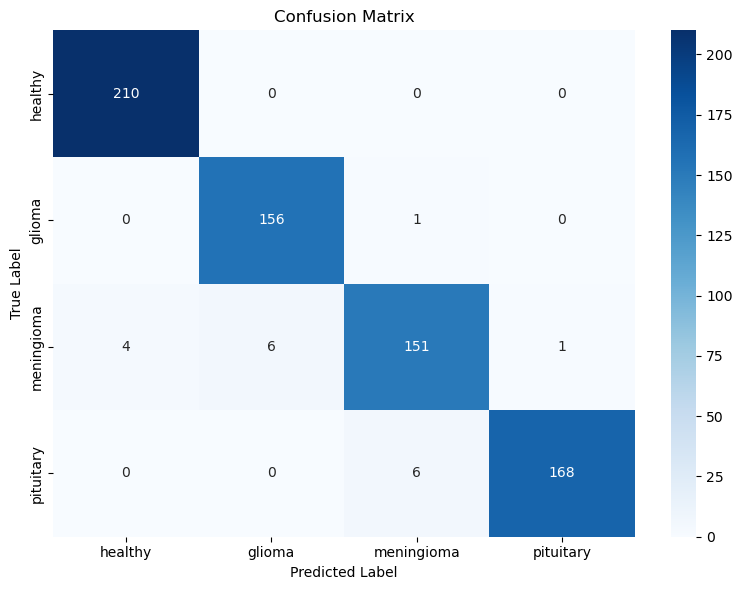

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

labels = ["healthy", "glioma", "meningioma", "pituitary"]  # swapped index 0 and 1

# Swap rows 0 and 1, then columns 0 and 1
swap = [1, 0, 2, 3]
swapped_cm = test_cm[np.ix_(swap, swap)]

plt.figure(figsize=(8, 6))
sns.heatmap(
    swapped_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
)
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

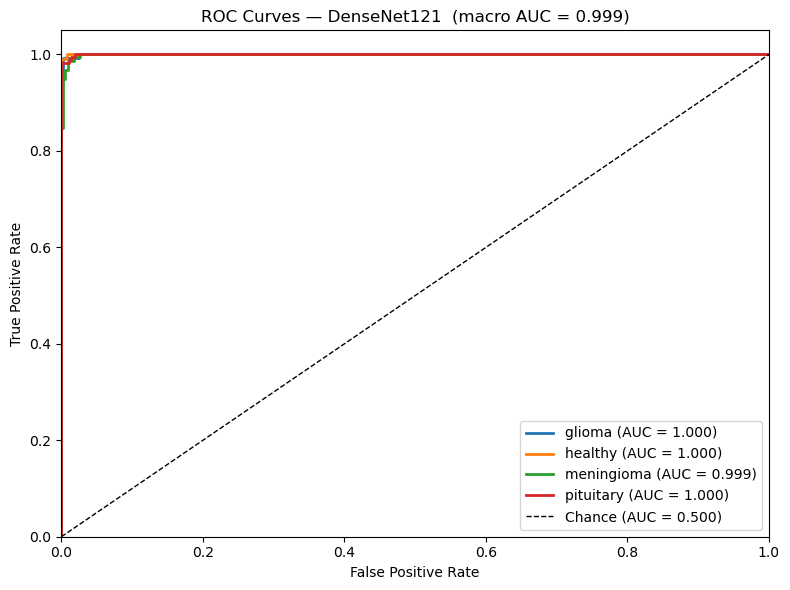

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

labels     = ["glioma", "healthy", "meningioma", "pituitary"]
n_classes  = len(labels)

# Binarize the true labels for one-vs-rest ROC
test_labels_bin = label_binarize(dns_val_labels, classes=np.arange(n_classes))

fig, ax = plt.subplots(figsize=(8, 6))

for i, label in enumerate(labels):
    fpr, tpr, _ = roc_curve(test_labels_bin[:, i], dns_val_probs[:, i])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, label=f"{label} (AUC = {roc_auc:.3f})")

# Chance line
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Chance (AUC = 0.500)")

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC Curves — DenseNet121  (macro AUC = {test_auc:.3f})")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

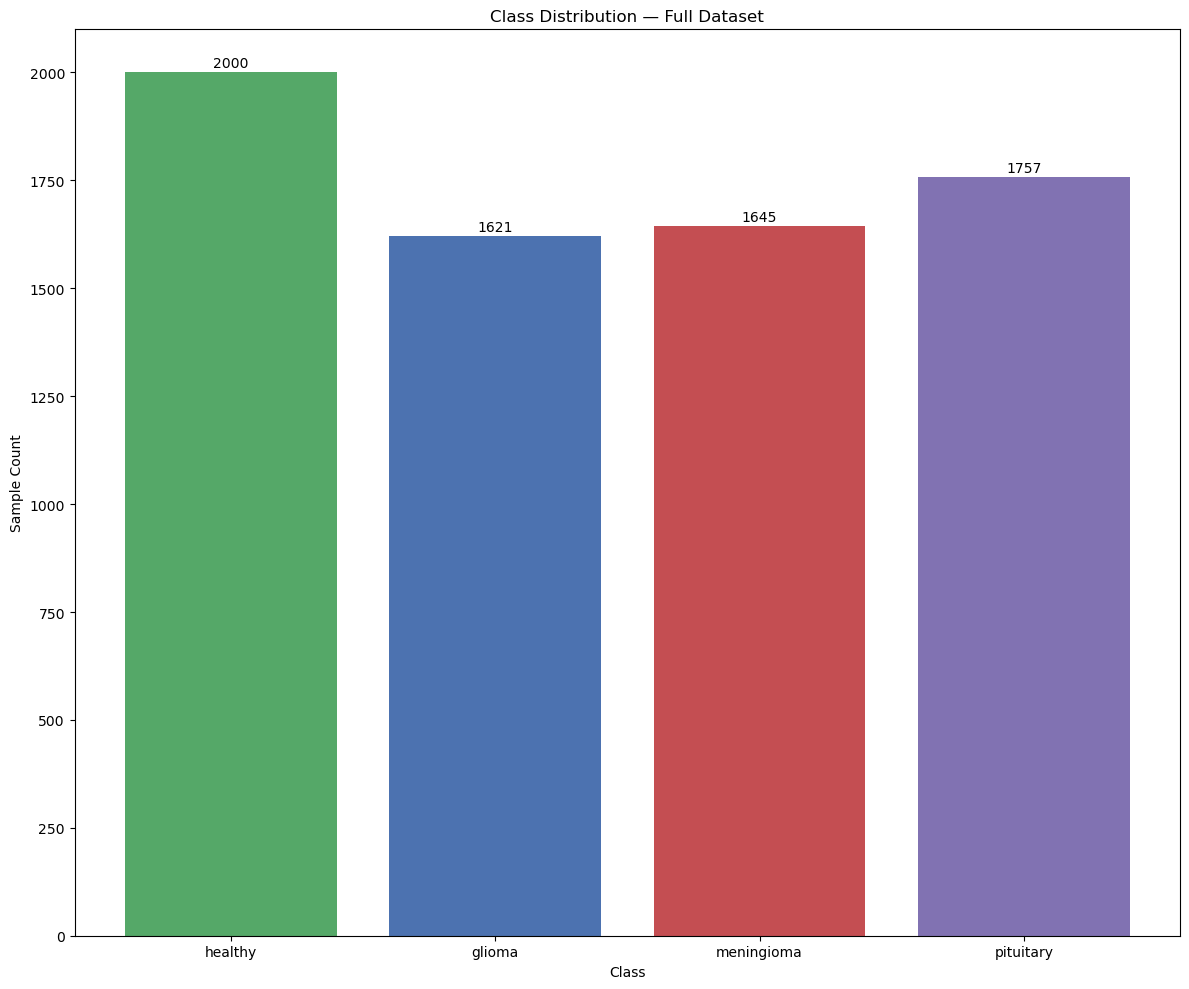

C:\Users\Trevo\AppData\Local\Temp\ipykernel_63336\2870932121.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


<Figure size 640x480 with 0 Axes>

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

label_names    = ["healthy", "glioma", "meningioma", "pituitary"]
original_order = [1, 0, 2, 3]  # healthy first (ImageFolder is alphabetical)

# Count across entire dataset
total_counts = Counter(label for _, label in dataset)
total_counts = [total_counts[i] for i in original_order]

fig, ax = plt.subplots(figsize=(12, 10))

bars = ax.bar(label_names, total_counts, color=["#55A868", "#4C72B0", "#C44E52", "#8172B2"])

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        str(int(bar.get_height())),
        ha="center", va="bottom", fontsize=10
    )

ax.set_xlabel("Class")
ax.set_ylabel("Sample Count")
ax.set_title("Class Distribution — Full Dataset")
plt.tight_layout()
plt.show()
ax.set_title("Class Distribution per Split")
ax.legend()
plt.tight_layout()
plt.show()